# 03 - Simple Baseline Model

This notebook keeps the machine-learning part intentionally small. The project is mainly about synthetic data generation and spatial EDA, so the model is only a sanity-check baseline.

Question: can cheap inline measurements predict the downstream resonance wavelength `lambda_res_nm` for dies that were tested downstream?

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = Path('..').resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / 'data'
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 40)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from src.utils import load_sources, merge_sources, validate_schemas


In [ ]:
df_inline, df_downstream = load_sources(input_dir=str(DATA_DIR), prefix='synthetic')
validate_schemas(df_inline, df_downstream)

df_model = merge_sources(df_inline, df_downstream, how='inner')
print(f'Modeling rows with downstream targets: {len(df_model)}')
display(df_model.head(3))

Loaded inline metrology: e:\Data_Science_Proj\data\synthetic_inline_metrology.csv
Loaded downstream wafer test: e:\Data_Science_Proj\data\synthetic_downstream_wafer_test.csv
Modeling rows with downstream targets: 3743


,wafer_id,die_id,test_station_id,lambda_res_nm,q_loaded,insertion_loss_db,test_pass,lot_id,x_mm,y_mm,r_mm,wg_width_nm_meas,soi_thickness_nm_meas,etch_depth_nm_meas,roughness_rms_nm_meas,overlay_x_nm_meas,overlay_y_nm_meas,defect_density_cm2_meas,metrology_valid,width_deviation,thickness_deviation,lambda_deviation
0,W011,D_R006_C003,TS3,1549.116065,150461.858416,5.025091,1,L01,-51.739130,-33.478261,61.625738,450.511287,217.082726,79.142618,1.772812,1.831545,-2.246708,1006.654324,1,0.511287,-2.917274,-0.883935
1,W017,D_R022_C014,TS2,1544.576533,172238.350848,5.021317,0,L02,15.217391,63.913043,65.699666,447.729463,217.379727,78.391870,1.556304,3.229459,-2.078630,812.628535,1,-2.270537,-2.620273,-5.423467
2,W005,D_R011_C017,TS2,1554.617178,171457.996705,5.018214,0,L05,33.478261,-3.043478,33.616316,451.681939,221.529149,80.379656,1.547459,-1.022446,2.111813,502.206865,1,1.681939,1.529149,4.617178


## Features and target

The target is `lambda_res_nm`. The input features are public inline measurements only. We do not use hidden true generator variables, downstream measurements, or the pass/fail label as model inputs.

In [ ]:
feature_cols = [
    'wg_width_nm_meas',
    'soi_thickness_nm_meas',
    'etch_depth_nm_meas',
    'roughness_rms_nm_meas',
    'overlay_x_nm_meas',
    'overlay_y_nm_meas',
    'defect_density_cm2_meas',
]
target_col = 'lambda_res_nm'

X = df_model[feature_cols]
y = df_model[target_col]

Features:
- wg_width_nm_meas
- soi_thickness_nm_meas
- etch_depth_nm_meas
- roughness_rms_nm_meas
- overlay_x_nm_meas
- overlay_y_nm_meas
- defect_density_cm2_meas
Target: lambda_res_nm


## Wafer holdout split

Instead of a random row split, we hold out complete wafers. This is more honest for manufacturing data because dies from the same wafer are correlated.

In [ ]:
wafer_ids = sorted(df_model['wafer_id'].unique())
test_wafers = wafer_ids[-4:]
train_mask = ~df_model['wafer_id'].isin(test_wafers)
test_mask = df_model['wafer_id'].isin(test_wafers)

train_df = df_model[train_mask].copy()
test_df = df_model[test_mask].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

print(f'Train wafers: {train_df["wafer_id"].nunique()} wafers, {len(train_df)} rows')
print(f'Test wafers: {test_wafers}, {len(test_df)} rows')

Train wafers: 16 wafers, 3003 rows
Test wafers: ['W017', 'W018', 'W019', 'W020'], 740 rows


## Linear regression baseline

The model is deliberately plain: standardize features, fit linear regression, evaluate on held-out wafers. This is enough to check whether the synthetic target is learnable from inline measurements.

In [ ]:
model = make_pipeline(StandardScaler(), LinearRegression())
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
metrics = {
    'RMSE_nm': np.sqrt(mean_squared_error(y_test, y_pred)),
    'MAE_nm': mean_absolute_error(y_test, y_pred),
    'R2': r2_score(y_test, y_pred),
}
display(pd.Series(metrics).to_frame('value'))

,value
RMSE_nm,0.814911
MAE_nm,0.648736
R2,0.831735


In [ ]:
linear_model = model.named_steps['linearregression']
coef_table = pd.DataFrame({
    'feature': feature_cols,
    'standardized_coefficient': linear_model.coef_,
})
coef_table = coef_table.reindex(
    coef_table['standardized_coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)
display(coef_table)

,feature,standardized_coefficient
0,wg_width_nm_meas,1.721339
1,soi_thickness_nm_meas,1.566636
2,defect_density_cm2_meas,-0.049012
3,roughness_rms_nm_meas,0.039291
4,etch_depth_nm_meas,0.018571
5,overlay_y_nm_meas,0.012981
6,overlay_x_nm_meas,0.007589


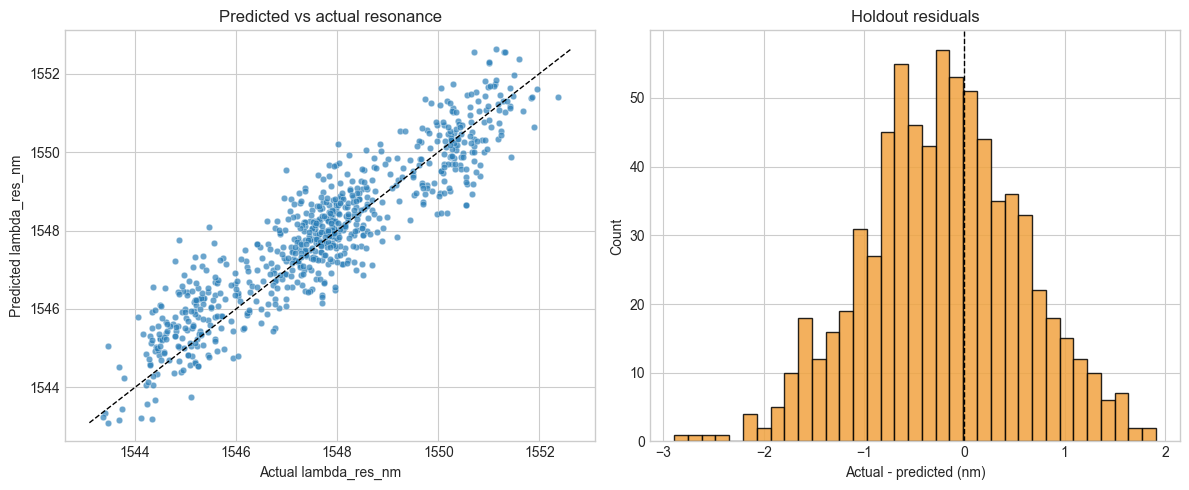

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, y_pred, s=22, alpha=0.7, color='#2C7FB8', edgecolor='white', linewidth=0.3)
min_v = min(y_test.min(), y_pred.min())
max_v = max(y_test.max(), y_pred.max())
axes[0].plot([min_v, max_v], [min_v, max_v], color='black', linestyle='--', linewidth=1)
axes[0].set_title('Predicted vs actual resonance')
axes[0].set_xlabel('Actual lambda_res_nm')
axes[0].set_ylabel('Predicted lambda_res_nm')

residuals = y_test - y_pred
axes[1].hist(residuals, bins=35, color='#F1A340', edgecolor='black', alpha=0.85)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Holdout residuals')
axes[1].set_xlabel('Actual - predicted (nm)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Interpretation

If the baseline performs well, that is expected: the generator intentionally makes `lambda_res_nm` depend mostly on width and thickness. The important point is not that linear regression is fancy. The important point is that the synthetic data story is internally consistent: the physics-inspired data generation leaves a visible signal in the public inline measurements.